# **Simulating the GCR-2 ansatz on a quantum circuit**

In [1]:
import ffsim
import ffsim.qiskit
import numpy as np
import pyscf
import pyscf.cc
import pyscf.gto
import pyscf.scf
from ffsim.qiskit.gates import PrepareHartreeFockJW
from ffsim.qiskit.gates.ucj import UCJOpSpinBalancedJW
from qiskit import QuantumCircuit

from xquces.igcr2 import IGCR2SpinBalancedParameterization
from xquces.qiskit import CircuitStatsJob, pretty_print_circuit_stats
from xquces.qiskit.gates.igcr2 import igcr2_stateprep_jw_circuit
from xquces.ucj.init import _ucj_ansatz_from_ffsim_stock


# **Nitrogen molecule: cc-pVDZ - equilibrium**

In [2]:
R = 1.1
basis = "cc-pvdz"
threads = 48
optimization_level = 3
transpile_seed = 12345


def build_ffsim_ucj_seed(t2, t1):
    return ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        np.asarray(t2, dtype=np.float64),
        t1=np.asarray(t1, dtype=np.complex128),
        n_reps=1,
    )


def ffsim_ucj_stateprep_jw_circuit(ucj_op, nelec):
    circuit = QuantumCircuit(2 * ucj_op.norb)
    circuit.append(PrepareHartreeFockJW(ucj_op.norb, nelec), circuit.qubits)
    circuit.append(UCJOpSpinBalancedJW(ucj_op), circuit.qubits)
    return circuit


def build_n2_circuits(r, basis):
    mol = pyscf.gto.Mole()
    mol.build(
        atom=[("N", (-0.5 * r, 0, 0)), ("N", (0.5 * r, 0, 0))],
        basis=basis,
        symmetry="Dooh",
        verbose=0,
    )

    scf = pyscf.scf.RHF(mol)
    scf.kernel()

    active_space = list(range(2, mol.nao_nr()))
    norb = len(active_space)
    nelectron_cas = int(round(sum(scf.mo_occ[active_space])))
    n_alpha = (nelectron_cas + mol.spin) // 2
    n_beta = (nelectron_cas - mol.spin) // 2
    nelec = (n_alpha, n_beta)

    ccsd = pyscf.cc.RCCSD(
        scf,
        frozen=[i for i in range(mol.nao_nr()) if i not in active_space],
    )
    ccsd.kernel()

    ffsim_ucj_seed = build_ffsim_ucj_seed(ccsd.t2, ccsd.t1)
    if ffsim_ucj_seed.final_orbital_rotation is None:
        raise RuntimeError("Expected ffsim UCJ seed to include a final orbital rotation.")

    ucj_seed = _ucj_ansatz_from_ffsim_stock(ffsim_ucj_seed)
    igcr2_param = IGCR2SpinBalancedParameterization(norb=norb, nocc=n_alpha)
    x_seed = igcr2_param.parameters_from_ucj_ansatz(ucj_seed)
    igcr2_ansatz = igcr2_param.ansatz_from_parameters(x_seed)

    return (
        ffsim_ucj_stateprep_jw_circuit(ffsim_ucj_seed, nelec),
        igcr2_stateprep_jw_circuit(igcr2_ansatz),
        norb,
        nelec,
        ffsim_ucj_seed.n_params(norb=norb, n_reps=1, with_final_orbital_rotation=True),
        igcr2_param.n_params,
    )

ffsim_circuit, igcr2_circuit, norb, nelec, ucj_n_params, igcr2_n_params = build_n2_circuits(
    r=R,
    basis=basis,
)

title = (
    f"N2/{basis} state-preparation circuit stats "
    f"(R={R:.3f} A, norb={norb}, nelec={nelec})"
)
print(f"parameters: ffsim UCJ = {ucj_n_params}, iGCR2 = {igcr2_n_params}\n")
pretty_print_circuit_stats(
    [
        CircuitStatsJob(
            "ffsim UCJ spin-balanced stateprep before PRE_INIT",
            ffsim_circuit,
        ),
        CircuitStatsJob(
            "ffsim UCJ spin-balanced stateprep after PRE_INIT",
            ffsim_circuit,
            pre_init=ffsim.qiskit.PRE_INIT,
        ),
        CircuitStatsJob("iGCR2 stateprep plain", igcr2_circuit),
    ],
    title=title,
    optimization_level=optimization_level,
    seed=transpile_seed,
)


parameters: ffsim UCJ = 2054, iGCR2 = 1484

N2/cc-pvdz state-preparation circuit stats (R=1.100 A, norb=26, nelec=(5, 5))
ffsim UCJ spin-balanced stateprep before PRE_INIT
-------------------------------------------------
qubits:          52
depth:           826
gates:           22525
two-qubit gates: 4092
ops:             cx: 4092, rz: 9968, sx: 8417, x: 48

ffsim UCJ spin-balanced stateprep after PRE_INIT
------------------------------------------------
qubits:          52
depth:           551
gates:           11448
two-qubit gates: 2060
ops:             cx: 2060, rz: 5055, sx: 4295, x: 38

iGCR2 stateprep plain
---------------------
qubits:          52
depth:           507
gates:           10769
two-qubit gates: 1976
ops:             cx: 1976, rz: 4634, sx: 4140, x: 19


[CircuitStats(label='ffsim UCJ spin-balanced stateprep before PRE_INIT', num_qubits=52, depth=826, gate_count=22525, two_qubit_gate_count=4092, count_ops={'rz': 9968, 'sx': 8417, 'cx': 4092, 'x': 48}),
 CircuitStats(label='ffsim UCJ spin-balanced stateprep after PRE_INIT', num_qubits=52, depth=551, gate_count=11448, two_qubit_gate_count=2060, count_ops={'rz': 5055, 'sx': 4295, 'cx': 2060, 'x': 38}),
 CircuitStats(label='iGCR2 stateprep plain', num_qubits=52, depth=507, gate_count=10769, two_qubit_gate_count=1976, count_ops={'rz': 4634, 'sx': 4140, 'cx': 1976, 'x': 19})]

# **$H_2$ circuit visualization and comparisons**

In [3]:
def build_h2_circuits(r, basis):
    mol = pyscf.gto.Mole()
    mol.build(
        atom=[("H", (-0.5 * r, 0, 0)), ("H", (0.5 * r, 0, 0))],
        basis=basis,
        symmetry="Dooh",
        verbose=0,
    )

    scf = pyscf.scf.RHF(mol)
    scf.kernel()

    active_space = list(range(mol.nao_nr()))
    norb = len(active_space)
    nelectron_cas = int(round(sum(scf.mo_occ[active_space])))
    n_alpha = (nelectron_cas + mol.spin) // 2
    n_beta = (nelectron_cas - mol.spin) // 2
    nelec = (n_alpha, n_beta)

    ccsd = pyscf.cc.RCCSD(scf)
    ccsd.kernel()

    ffsim_ucj_seed = build_ffsim_ucj_seed(ccsd.t2, ccsd.t1)
    if ffsim_ucj_seed.final_orbital_rotation is None:
        raise RuntimeError("Expected ffsim UCJ seed to include a final orbital rotation.")

    ucj_seed = _ucj_ansatz_from_ffsim_stock(ffsim_ucj_seed)
    igcr2_param = IGCR2SpinBalancedParameterization(norb=norb, nocc=n_alpha)
    x_seed = igcr2_param.parameters_from_ucj_ansatz(ucj_seed)
    igcr2_ansatz = igcr2_param.ansatz_from_parameters(x_seed)

    return (
        ffsim_ucj_stateprep_jw_circuit(ffsim_ucj_seed, nelec),
        igcr2_stateprep_jw_circuit(igcr2_ansatz),
        norb,
        nelec,
        ffsim_ucj_seed.n_params(norb=norb, n_reps=1, with_final_orbital_rotation=True),
        igcr2_param.n_params,
    )


In [4]:
h2_R = 0.74
h2_basis = "sto-6g"

h2_ffsim_circuit, h2_igcr2_circuit, h2_norb, h2_nelec, h2_ucj_n_params, h2_igcr2_n_params = build_h2_circuits(
    r=h2_R,
    basis=h2_basis,
)

print(f"\nH2/{h2_basis} visualization circuits (R={h2_R:.3f} A, norb={h2_norb}, nelec={h2_nelec})")
print(f"parameters: ffsim UCJ = {h2_ucj_n_params}, iGCR2 = {h2_igcr2_n_params}")

h2_ffsim_givens_circuit = h2_ffsim_circuit.decompose(reps=2)
h2_igcr2_givens_circuit = h2_igcr2_circuit.decompose(reps=1)


H2/sto-6g visualization circuits (R=0.740 A, norb=2, nelec=(1, 1))
parameters: ffsim UCJ = 14, iGCR2 = 7


# ffsim UCJ

ffsim visible ops: {'p': 16, 'xx_plus_yy': 6, 'cp': 6, 'x': 2, 'global_phase': 1}


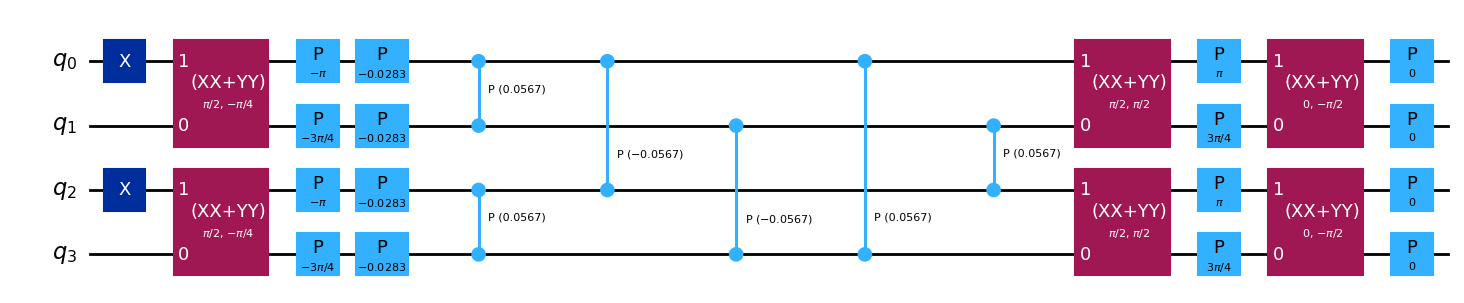

In [5]:
print("ffsim visible ops:", dict(h2_ffsim_givens_circuit.count_ops()))
h2_ffsim_givens_circuit.draw("mpl", fold=-1, idle_wires=False)

# ffsim UCJ after pre_init

ffsim after PRE_INIT visible ops: {'p': 8, 'cp': 6, 'xx_plus_yy': 4, 'x': 2, 'global_phase': 1}


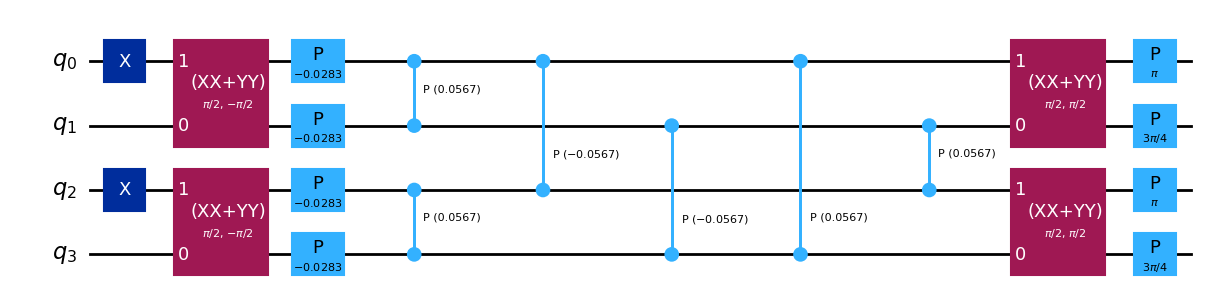

In [6]:
import ffsim.qiskit

h2_ffsim_after_pre_init_givens = ffsim.qiskit.PRE_INIT.run(h2_ffsim_circuit)

print("ffsim after PRE_INIT visible ops:", dict(h2_ffsim_after_pre_init_givens.decompose(reps=1).count_ops()))
h2_ffsim_after_pre_init_givens.decompose(reps=1).draw("mpl", fold=-1, idle_wires=False)

# xquces iGCR-2

iGCR2 visible ops: {'xx_plus_yy': 4, 'p': 4, 'x': 2, 'rzz': 2, 'global_phase': 1}


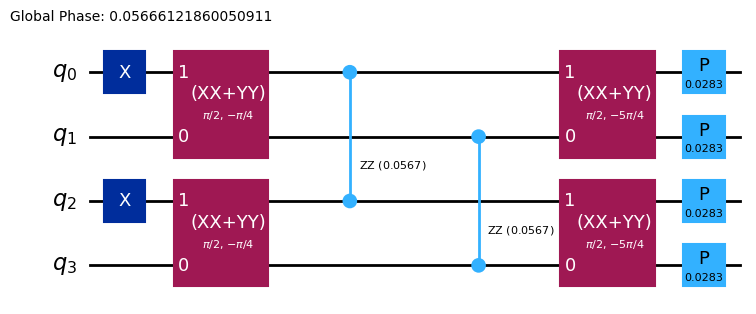

In [7]:
print("iGCR2 visible ops:", dict(h2_igcr2_givens_circuit.count_ops()))
h2_igcr2_givens_circuit.draw("mpl", fold=-1, idle_wires=False)

In [8]:
from qiskit.quantum_info import Statevector
from xquces.basis import occ_rows
from xquces.hamiltonians import MolecularHamiltonianLinearOperator


def bitstring_index(occ_alpha, occ_beta, norb):
    alpha_bits = sum(1 << int(p) for p in occ_alpha)
    beta_bits = sum(1 << (norb + int(p)) for p in occ_beta)
    return alpha_bits + beta_bits


def jw_state_to_sector(vec, norb, nelec):
    occ_alpha = occ_rows(norb, nelec[0])
    occ_beta = occ_rows(norb, nelec[1])
    out = np.zeros((len(occ_alpha), len(occ_beta)), dtype=np.complex128)

    for i_alpha, alpha in enumerate(occ_alpha):
        for i_beta, beta in enumerate(occ_beta):
            out[i_alpha, i_beta] = vec[bitstring_index(alpha, beta, norb)]

    return out.reshape(-1)


def stateprep_sector_state(circuit, norb, nelec):
    full_state = Statevector.from_label("0" * (2 * norb)).evolve(circuit).data
    return jw_state_to_sector(full_state, norb, nelec)


def phase_aligned_diff(psi, phi):
    overlap = np.vdot(phi, psi)
    if abs(overlap) < 1e-14:
        return np.linalg.norm(psi - phi)
    return np.linalg.norm(psi - overlap / abs(overlap) * phi)


# Rebuild the H2 SCF object for the Hamiltonian.
h2_mol = pyscf.gto.Mole()
h2_mol.build(
    atom=[("H", (-0.5 * h2_R, 0, 0)), ("H", (0.5 * h2_R, 0, 0))],
    basis=h2_basis,
    symmetry="Dooh",
    verbose=0,
)

h2_scf = pyscf.scf.RHF(h2_mol)
h2_scf.kernel()

h2_active_space = list(range(h2_mol.nao_nr()))
h2_ham = MolecularHamiltonianLinearOperator.from_scf(
    h2_scf,
    active_space=h2_active_space,
)

# Use the ffsim PRE_INIT-only circuit if you built it already.
h2_ffsim_after_pre_init_givens = ffsim.qiskit.PRE_INIT.run(h2_ffsim_circuit).decompose(reps=1)

psi_ffsim_before = stateprep_sector_state(h2_ffsim_circuit, h2_norb, h2_nelec)
psi_ffsim_after = stateprep_sector_state(h2_ffsim_after_pre_init_givens, h2_norb, h2_nelec)
psi_igcr2 = stateprep_sector_state(h2_igcr2_circuit, h2_norb, h2_nelec)

states = {
    "ffsim before PRE_INIT": psi_ffsim_before,
    "ffsim after PRE_INIT": psi_ffsim_after,
    "iGCR2": psi_igcr2,
}

reference_name = "ffsim before PRE_INIT"
reference_state = states[reference_name]

print("Energies")
print("--------")
for name, psi in states.items():
    energy = h2_ham.expectation(psi)
    print(f"{name:24s}: {energy:.16f}")

print()
print(f"Overlaps with {reference_name}")
print("--------------------------------")
for name, psi in states.items():
    overlap = np.vdot(reference_state, psi)
    print(
        f"{name:24s}: "
        f"|overlap| = {abs(overlap):.16f}, "
        f"phase-aligned diff = {phase_aligned_diff(psi, reference_state):.3e}"
    )

print("\nParameters")
print("----------")
print(f"ffsim UCJ: {h2_ucj_n_params}")
print(f"iGCR2:     {h2_igcr2_n_params}")

print()
print("Circuit stats")
print("-------------")
print(
    f"{'circuit':28s} "
    f"{'depth':>8s} "
    f"{'gates':>8s} "
    f"{'ops'}"
)

for name, circuit in [
    ("ffsim before PRE_INIT", h2_ffsim_givens_circuit),
    ("ffsim after PRE_INIT", h2_ffsim_after_pre_init_givens),
    ("iGCR2", h2_igcr2_givens_circuit),
]:
    ops = dict(circuit.count_ops())
    gate_count = sum(ops.values())
    ops_text = ", ".join(f"{gate}: {count}" for gate, count in sorted(ops.items()))
    print(f"{name:28s} {circuit.depth():8d} {gate_count:8d} {ops_text}")


Energies
--------
ffsim before PRE_INIT   : -1.1408254570223193
ffsim after PRE_INIT    : -1.1408254570223193
iGCR2                   : -1.1408254570223197

Overlaps with ffsim before PRE_INIT
--------------------------------
ffsim before PRE_INIT   : |overlap| = 1.0000000000000002, phase-aligned diff = 0.000e+00
ffsim after PRE_INIT    : |overlap| = 1.0000000000000002, phase-aligned diff = 2.249e-16
iGCR2                   : |overlap| = 1.0000000000000002, phase-aligned diff = 4.975e-16

Parameters
----------
ffsim UCJ: 14
iGCR2:     7

Circuit stats
-------------
circuit                         depth    gates ops
ffsim before PRE_INIT              11       31 cp: 6, global_phase: 1, p: 16, x: 2, xx_plus_yy: 6
ffsim after PRE_INIT                8       21 cp: 6, global_phase: 1, p: 8, x: 2, xx_plus_yy: 4
iGCR2                               5       13 global_phase: 1, p: 4, rzz: 2, x: 2, xx_plus_yy: 4


# **$H_4$ square circuit visualization and comparisons**

In [90]:
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import UnrollCustomDefinitions
from qiskit.circuit.equivalence_library import SessionEquivalenceLibrary

BASIS_GATES = ["xx_plus_yy", "cp", "p", "x", "mcphase"]

# UnrollCustomDefinitions does one DAG pass per call (no recursion within a pass),
# so repeat enough times to cover the gate nesting depth.
_unroll_pass = UnrollCustomDefinitions(SessionEquivalenceLibrary, basis_gates=BASIS_GATES)
_pm_to_basis = PassManager([_unroll_pass] * 6)

def decompose_to_basis(circuit):
    return _pm_to_basis.run(circuit)


In [91]:
from xquces.igcr2 import IGCR2SpinRestrictedParameterization
from xquces.igcr3 import IGCR3SpinRestrictedParameterization
from xquces.qiskit.gates.igcr3 import igcr3_stateprep_jw_circuit
from xquces.ucj.init import UCJRestrictedProjectedDFSeed

h4_R = 1.2
h4_basis = "sto-6g"


def build_h4_circuits(r, basis):
    half = 0.5 * r
    mol = pyscf.gto.Mole()
    mol.build(
        atom=[
            ("H", (-half, -half, 0.0)),
            ("H", ( half, -half, 0.0)),
            ("H", ( half,  half, 0.0)),
            ("H", (-half,  half, 0.0)),
        ],
        basis=basis,
        symmetry=False,
        unit="Angstrom",
        verbose=0,
    )

    scf = pyscf.scf.RHF(mol)
    scf.kernel()

    active_space = list(range(mol.nao_nr()))
    norb = len(active_space)
    nelectron_cas = int(round(sum(scf.mo_occ[active_space])))
    n_alpha = (nelectron_cas + mol.spin) // 2
    n_beta  = (nelectron_cas - mol.spin) // 2
    nelec = (n_alpha, n_beta)

    ccsd = pyscf.cc.RCCSD(scf)
    ccsd.kernel()

    # ffsim UCJ (spin-balanced) -- for the ffsim circuit only.
    ffsim_ucj_seed = build_ffsim_ucj_seed(ccsd.t2, ccsd.t1)
    if ffsim_ucj_seed.final_orbital_rotation is None:
        raise RuntimeError("Expected ffsim UCJ seed to include a final orbital rotation.")

    # xquces spin-restricted UCJ -- for seeding iGCR2 and iGCR3.
    ucj_restricted_seed = UCJRestrictedProjectedDFSeed(
        t2=ccsd.t2, t1=ccsd.t1, n_reps=1
    ).build_ansatz()

    igcr2_param = IGCR2SpinRestrictedParameterization(
        norb=norb, nocc=n_alpha, real_right_orbital_chart=True
    )
    x_igcr2 = igcr2_param.parameters_from_ucj_ansatz(ucj_restricted_seed)
    igcr2_ansatz = igcr2_param.ansatz_from_parameters(x_igcr2)

    igcr3_param = IGCR3SpinRestrictedParameterization(
        norb=norb, nocc=n_alpha, real_right_orbital_chart=True
    )
    x_igcr3 = igcr3_param.parameters_from_ucj_ansatz(ucj_restricted_seed, tau_scale=1.0, omega_scale=1.0)
    igcr3_ansatz = igcr3_param.ansatz_from_parameters(x_igcr3)

    return (
        ffsim_ucj_stateprep_jw_circuit(ffsim_ucj_seed, nelec),
        igcr2_stateprep_jw_circuit(igcr2_ansatz),
        igcr3_stateprep_jw_circuit(igcr3_ansatz),
        norb,
        nelec,
        ffsim_ucj_seed.n_params(norb=norb, n_reps=1, with_final_orbital_rotation=True),
        igcr2_param.n_params,
        igcr3_param.n_params,
        igcr3_param.sector_sizes(),
    )


(
    h4_ffsim_circuit,
    h4_igcr2_circuit,
    h4_igcr3_circuit,
    h4_norb,
    h4_nelec,
    h4_ucj_n_params,
    h4_igcr2_n_params,
    h4_igcr3_n_params,
    h4_igcr3_sectors,
) = build_h4_circuits(r=h4_R, basis=h4_basis)

h4_ffsim_givens_circuit = decompose_to_basis(h4_ffsim_circuit)
h4_ffsim_after_pre_init = decompose_to_basis(ffsim.qiskit.PRE_INIT.run(h4_ffsim_circuit))
h4_igcr2_givens_circuit = decompose_to_basis(h4_igcr2_circuit)
h4_igcr3_givens_circuit = decompose_to_basis(h4_igcr3_circuit)


In [87]:
from xquces.hamiltonians import MolecularHamiltonianLinearOperator

# Rebuild SCF for Hamiltonian evaluation.
_h4_half = 0.5 * h4_R
h4_mol = pyscf.gto.Mole()
h4_mol.build(
    atom=[
        ("H", (-_h4_half, -_h4_half, 0.0)),
        ("H", ( _h4_half, -_h4_half, 0.0)),
        ("H", ( _h4_half,  _h4_half, 0.0)),
        ("H", (-_h4_half,  _h4_half, 0.0)),
    ],
    basis=h4_basis,
    symmetry=False,
    unit="Angstrom",
    verbose=0,
)
h4_scf = pyscf.scf.RHF(h4_mol)
h4_scf.kernel()
h4_ham = MolecularHamiltonianLinearOperator.from_scf(h4_scf, active_space=list(range(h4_mol.nao_nr())))

psi_h4_ffsim_before   = stateprep_sector_state(h4_ffsim_circuit, h4_norb, h4_nelec)
psi_h4_ffsim_after    = stateprep_sector_state(
    ffsim.qiskit.PRE_INIT.run(h4_ffsim_circuit).decompose(reps=1), h4_norb, h4_nelec
)
psi_h4_igcr2          = stateprep_sector_state(h4_igcr2_circuit, h4_norb, h4_nelec)
psi_h4_igcr3          = stateprep_sector_state(h4_igcr3_circuit, h4_norb, h4_nelec)

h4_states = {
    "ffsim UCJ before PRE_INIT": psi_h4_ffsim_before,
    "ffsim UCJ after PRE_INIT":  psi_h4_ffsim_after,
    "iGCR2 (spin-restricted)":   psi_h4_igcr2,
    "iGCR3 (spin-restricted)":   psi_h4_igcr3,
}

h4_reference_name  = "ffsim UCJ before PRE_INIT"
h4_reference_state = h4_states[h4_reference_name]

print("Energies")
print("--------")
for name, psi in h4_states.items():
    energy = h4_ham.expectation(psi)
    print(f"{name:34s}: {energy:.16f}")

print()
print(f"Overlaps with {h4_reference_name}")
print("-" * (15 + len(h4_reference_name)))
for name, psi in h4_states.items():
    overlap = np.vdot(h4_reference_state, psi)
    print(
        f"{name:34s}: "
        f"|overlap| = {abs(overlap):.10f}, "
        f"phase-aligned diff = {phase_aligned_diff(psi, h4_reference_state):.3e}"
    )

print("\nParameters")
print("----------")
print(f"ffsim UCJ: {h4_ucj_n_params}")
print(f"iGCR2:     {h4_igcr2_n_params}")
print(f"iGCR3:     {h4_igcr3_n_params}  {h4_igcr3_sectors}")

print()
print("Circuit stats (decomposed to Givens level)")
print("-------------------------------------------")
print(f"{'circuit':34s} {'depth':>6s} {'gates':>6s} {'ops'}")
for name, circuit in [
    ("ffsim UCJ before PRE_INIT", h4_ffsim_givens_circuit),
    ("ffsim UCJ after PRE_INIT",  h4_ffsim_after_pre_init),
    ("iGCR2 (spin-restricted)",   h4_igcr2_givens_circuit),
    ("iGCR3 (spin-restricted)",   h4_igcr3_givens_circuit),
]:
    ops = dict(circuit.count_ops())
    gate_count = sum(ops.values())
    ops_text = ", ".join(f"{g}: {c}" for g, c in sorted(ops.items()))
    print(f"{name:34s} {circuit.depth():6d} {gate_count:6d} {ops_text}")

Energies
--------
ffsim UCJ before PRE_INIT         : -1.7009021832931697
ffsim UCJ after PRE_INIT          : -1.7009021832931706
iGCR2 (spin-restricted)           : -1.7009021832931794
iGCR3 (spin-restricted)           : -1.6993850490850613

Overlaps with ffsim UCJ before PRE_INIT
----------------------------------------
ffsim UCJ before PRE_INIT         : |overlap| = 1.0000000000, phase-aligned diff = 0.000e+00
ffsim UCJ after PRE_INIT          : |overlap| = 1.0000000000, phase-aligned diff = 1.087e-11
iGCR2 (spin-restricted)           : |overlap| = 1.0000000000, phase-aligned diff = 1.087e-11
iGCR3 (spin-restricted)           : |overlap| = 0.9986965872, phase-aligned diff = 5.106e-02

Parameters
----------
ffsim UCJ: 52
iGCR2:     22
iGCR3:     28  {'left': 12, 'double': 0, 'pair': 6, 'tau': 0, 'omega': 0, 'cubic': 6, 'right': 4, 'total': 28}

Circuit stats (decomposed to Givens level)
-------------------------------------------
circuit                             depth  gates ops
f

# GCR-2

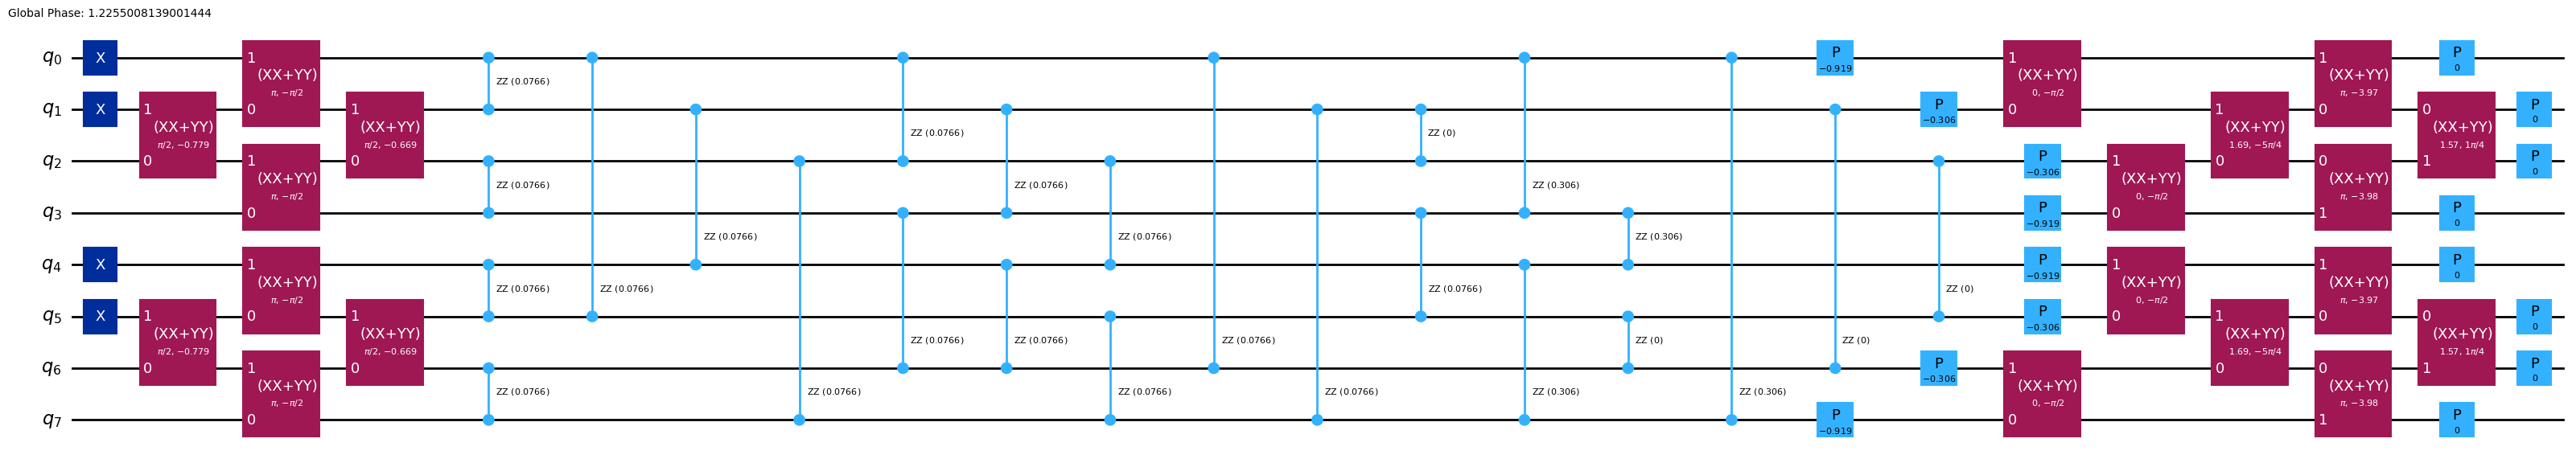

In [92]:
h4_igcr2_givens_circuit.draw("mpl", fold=-1, idle_wires=False)

# GCR-3

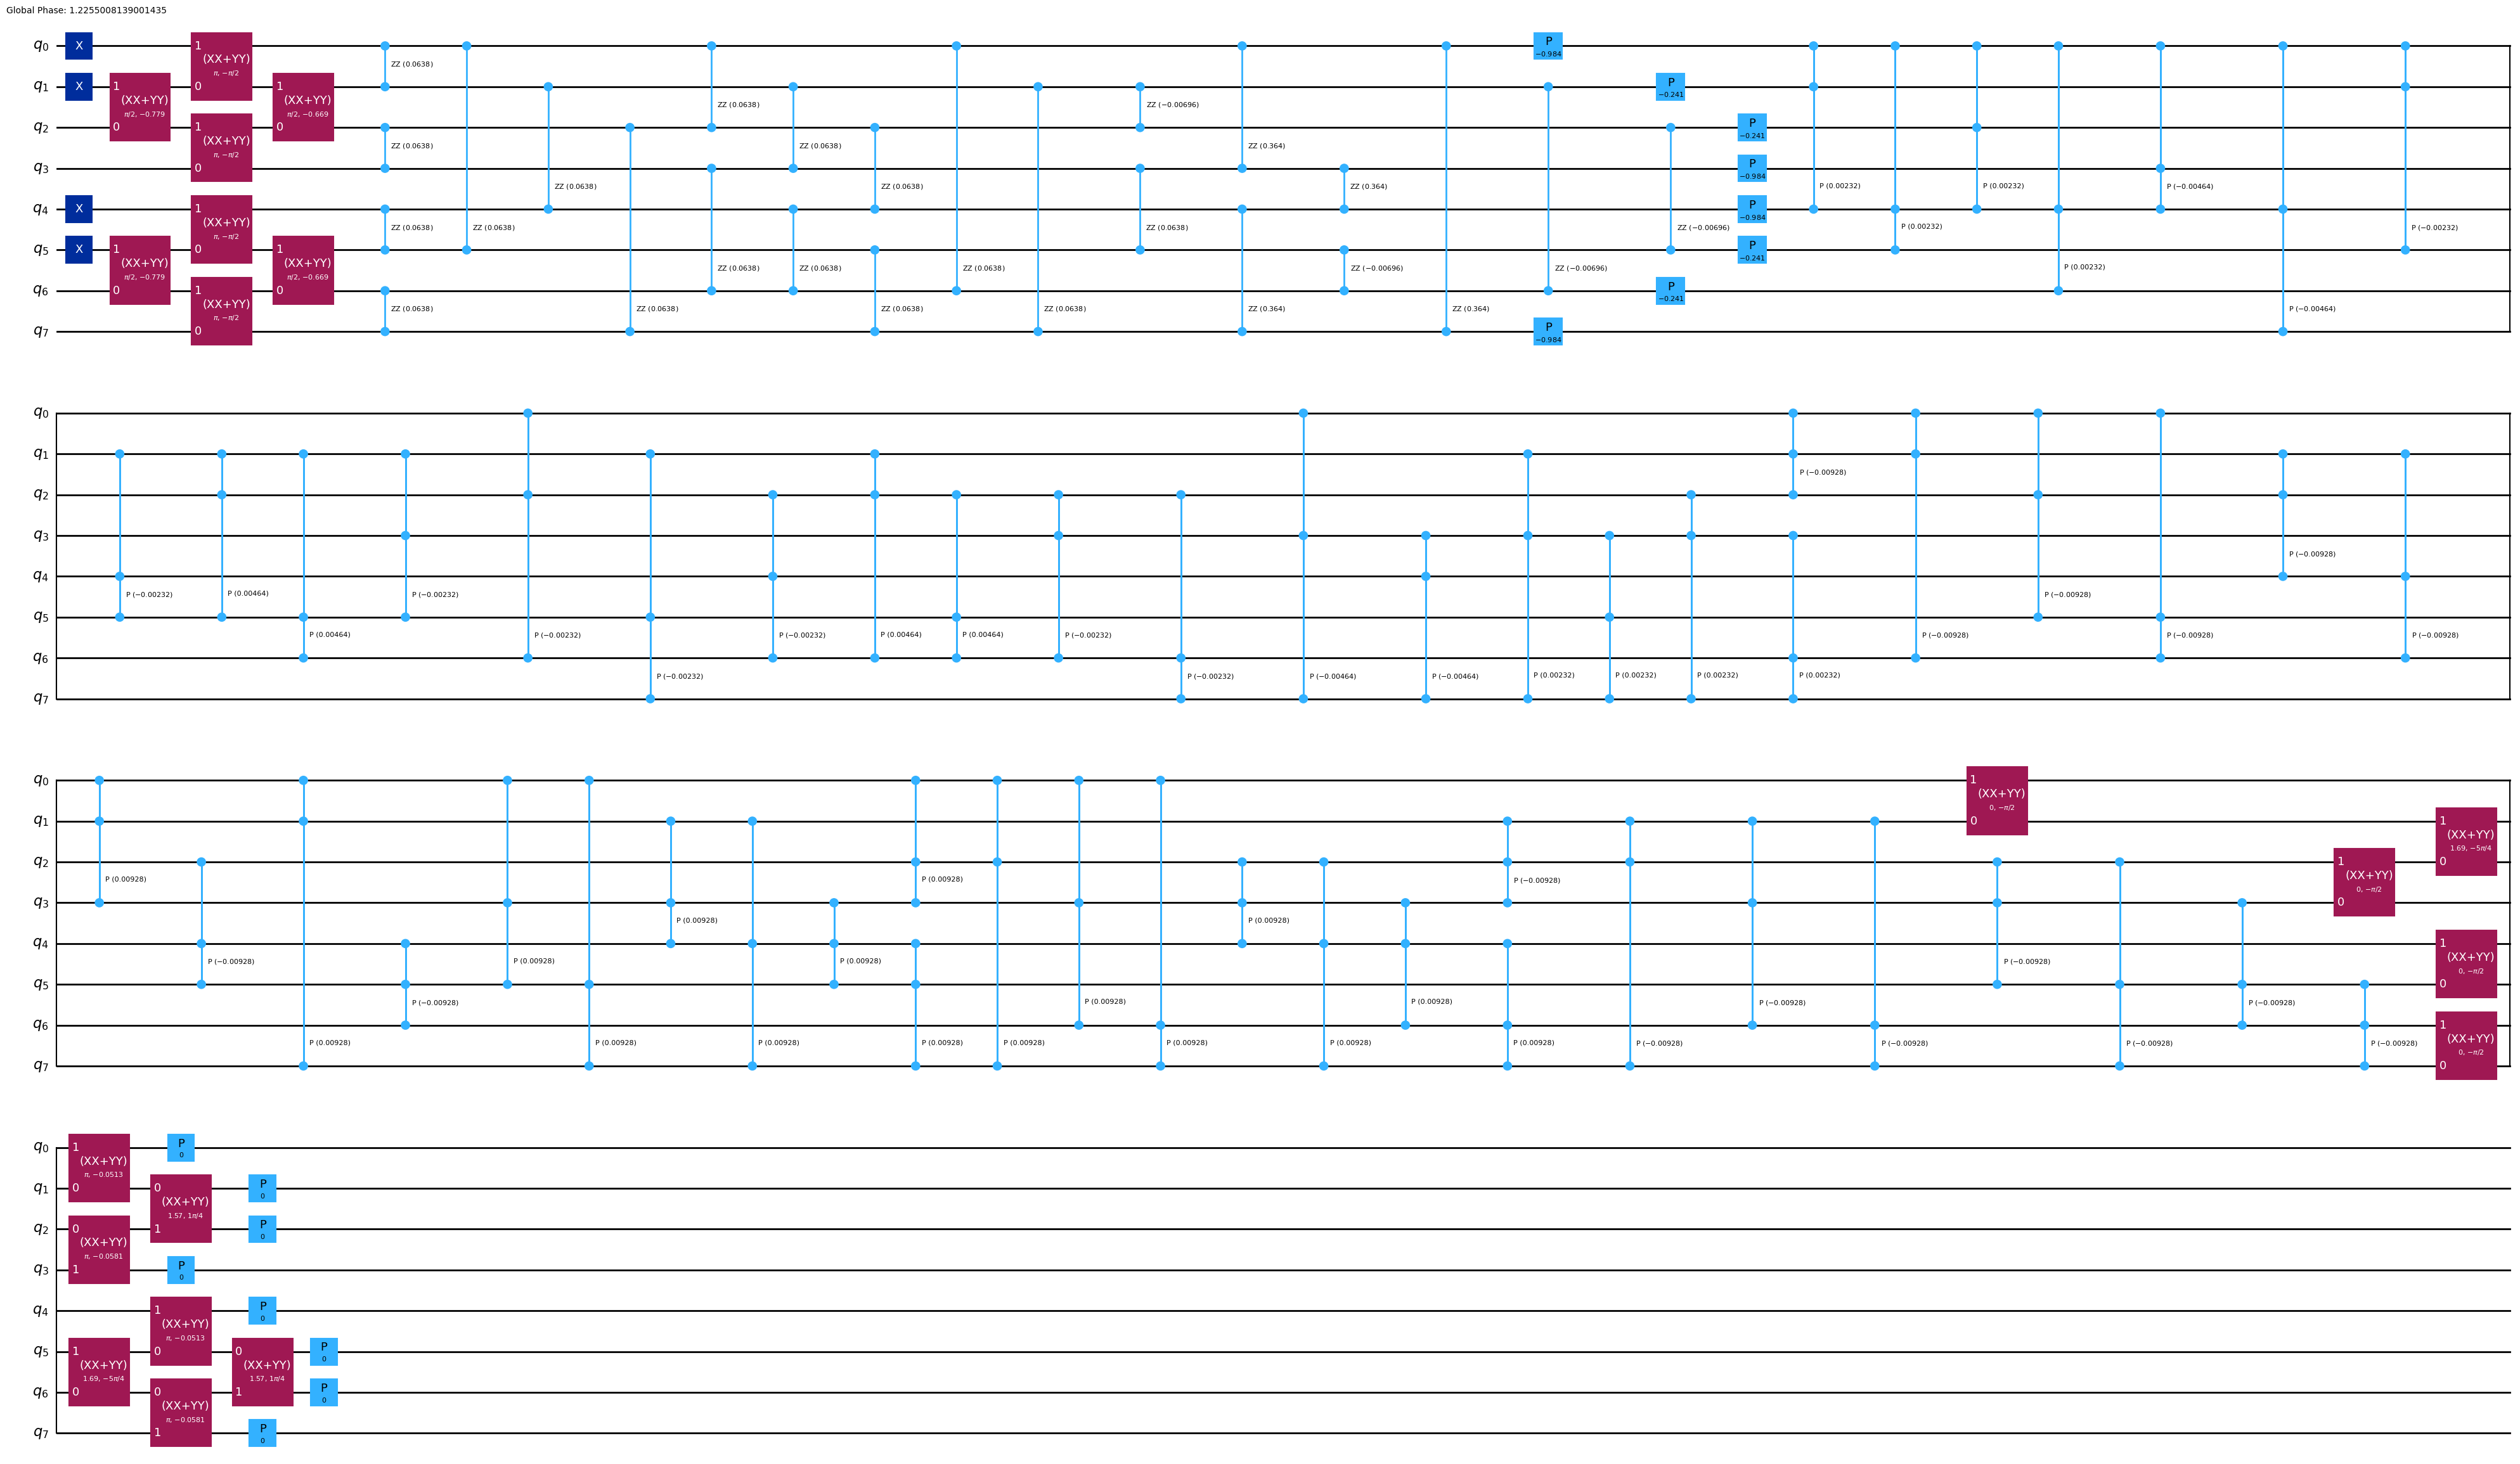

In [93]:
h4_igcr3_givens_circuit.draw("mpl", fold=60, idle_wires=False)